<a href="https://colab.research.google.com/github/kjcline-spec/NBA-Analytics-Final-Project/blob/main/HW_1_KJ_Cline_COMPAS_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPAS Analysis — Python Replication

Replicates ProPublica's COMPAS Recidivism Risk Score analysis, translating the Lecture 01 R workflow
into Python. Covers EDA, logistic regression, and model diagnostics.

Methodology: https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores,
and whether each person was accused of a crime within two years.

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import math
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load raw data ─────────────────────────────────────────────────────────────
# R: raw_data <- read.csv(url, stringsAsFactors = FALSE)

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(f"Raw rows: {len(raw_data)}")   # Expect 7214

Raw rows: 7214


In [ ]:
# ── Preview ───────────────────────────────────────────────────────────────────
# R: head(raw_data, 10)
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons to remove rows because of missing data:
* If the charge date of a defendant's COMPAS scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a COMPAS case at all.
* Ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in jail time and are removed.
* We filtered to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
# ── Select columns, filter, convert types, build derived factor variables ─────
# R: dplyr::select(...) %>% filter(...) %>% mutate(across(...)) %>% mutate(relevel(...))

numeric_vars  = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

cols = [
    'age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'decile_score',
    'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out'
]

df = (
    raw_data[cols].copy()
    # ── Filtering ──────────────────────────────────────────────────────
    .query("days_b_screening_arrest >= -30 and days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .reset_index(drop=True)
)

# ── Type conversions ───────────────────────────────────────────────────
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# ── Derived factors with reference levels (mirrors R relevel) ─────────
# age_factor:    ref = '25 - 45'
# race_factor:   ref = 'Caucasian'
# gender_factor: ref = 'Male'
# crime_factor:  ref = 'F' (felony)
# score_factor:  LowScore vs HighScore

df['crime_factor']  = pd.Categorical(df['c_charge_degree'],
                                     categories=['F', 'M'])
df['age_factor']    = pd.Categorical(df['age_cat'],
                                     categories=['25 - 45', 'Greater than 45', 'Less than 25'])
df['race_factor']   = pd.Categorical(df['race'],
                                     categories=['Caucasian', 'African-American', 'Asian',
                                                 'Hispanic', 'Native American', 'Other'])
df['gender_factor'] = pd.Categorical(df['sex'],
                                     categories=['Male', 'Female'])
df['score_factor']  = pd.Categorical(
    np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'),
    categories=['LowScore', 'HighScore']
)

print(f"Filtered rows: {len(df)}")   # Expect 6172

Filtered rows: 6172


In [ ]:
# ── head(df) ──────────────────────────────────────────────────────────────────
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [ ]:
# ── glimpse(df) ───────────────────────────────────────────────────────────────
# R: glimpse(df)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 6172, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
# ── Correlation: length of stay vs decile score ───────────────────────────────
# R: df$length_of_stay <- as.numeric(...); cor(df$length_of_stay, df$decile_score)

df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

valid = df[['length_of_stay', 'decile_score']].dropna()
r, _ = stats.pearsonr(valid['length_of_stay'], valid['decile_score'])
print(f"Correlation (length_of_stay vs decile_score): {r:.7f}")   # Expect ~0.207

Correlation (length_of_stay vs decile_score): 0.2074781


After filtering we have the following demographic breakdown:

In [ ]:
# ── Age category breakdown ────────────────────────────────────────────────────
# R: summary(df$age_cat)
print(df['age_cat'].value_counts().sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [ ]:
# ── Race breakdown ────────────────────────────────────────────────────────────
# R: summary(df$race)
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
# ── Race percentages ──────────────────────────────────────────────────────────
n = len(df)
rc = df['race'].value_counts()

print(f"Black defendants:           {rc.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants:           {rc.get('Caucasian', 0)        / n * 100:.2f}%")
print(f"Hispanic defendants:        {rc.get('Hispanic', 0)         / n * 100:.2f}%")
print(f"Asian defendants:           {rc.get('Asian', 0)            / n * 100:.2f}%")
print(f"Native American defendants: {rc.get('Native American', 0)  / n * 100:.2f}%")

Black defendants:           51.44%
White defendants:           34.07%
Hispanic defendants:        8.25%
Asian defendants:           0.50%
Native American defendants: 0.18%


In [ ]:
# ── Score text distribution ───────────────────────────────────────────────────
# R: summary(df$score_text)
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
# ── Cross-tab: sex × race ─────────────────────────────────────────────────────
# R: xtabs(~ sex + race, data=df)
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [ ]:
# ── Sex distribution and percentages ─────────────────────────────────────────
# R: summary(df$sex)
sc = df['sex'].value_counts()
print(sc)
print(f"\nMen:   {sc.get('Male',   0) / n * 100:.2f}%")
print(f"Women: {sc.get('Female', 0) / n * 100:.2f}%")

sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [ ]:
# ── Two-year recidivism count and rate ────────────────────────────────────────
# R: nrow(filter(df, two_year_recid == 1))
#    nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100

recid_count = (df['two_year_recid'] == 1).sum()
print(f"Two-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / n * 100:.2f}%")

Two-year recidivists: 2809
Recidivism rate:      45.51%


Judges are often presented with two sets of scores from the COMPAS system — one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

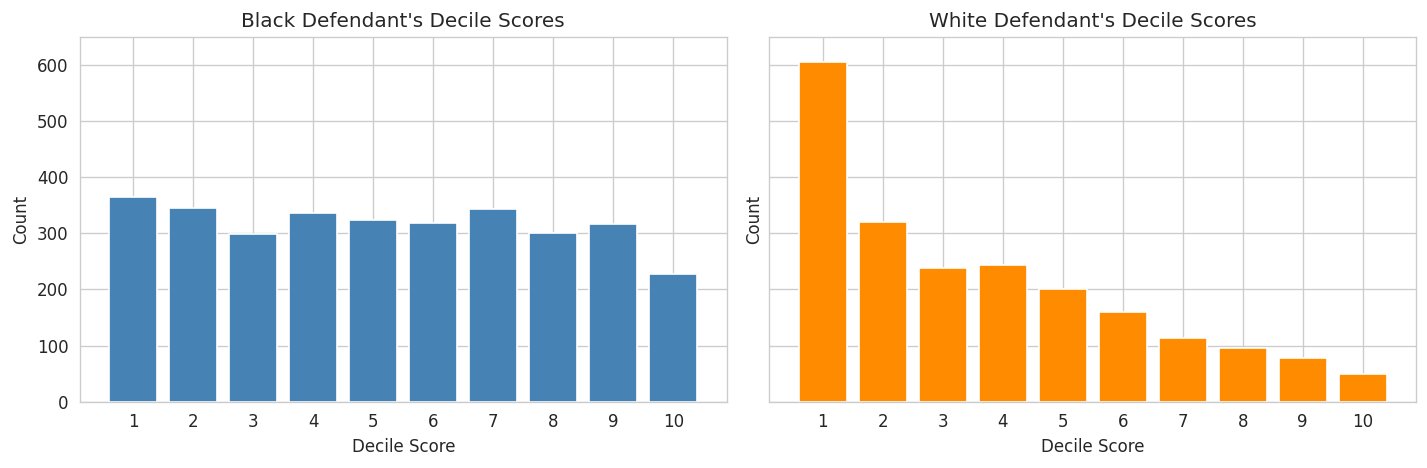

In [ ]:
# ── Decile score bar charts: Black vs White defendants ────────────────────────
# R: ggplot + geom_bar + grid.arrange

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, race, title, color in zip(
    axes,
    ['African-American', 'Caucasian'],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"],
    ['steelblue', 'darkorange']
):
    counts = df[df['race'] == race]['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_xlabel('Decile Score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [ ]:
# ── Cross-tab: decile score × race ───────────────────────────────────────────
# R: xtabs(~ decile_score + race, data=df)
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in COMPAS

After filtering out bad rows, our first question is whether there is a significant difference in COMPAS
scores between races. To do so we need to change some variables into factors, and run a logistic
regression, comparing low scores to high scores.

In [ ]:
# ── Logistic regression ───────────────────────────────────────────────────────
# R: glm(score_factor ~ gender_factor + age_factor + race_factor +
#         priors_count + crime_factor + two_year_recid, family=binomial)
#
# Reference levels (mirrors R relevel):
#   gender_factor → 'Male'
#   age_factor    → '25 - 45'
#   race_factor   → 'Caucasian'
#   crime_factor  → 'F'

df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

formula = (
    "score_binary ~ "
    "C(sex,              Treatment(reference='Male')) + "
    "C(age_cat,          Treatment(reference='25 - 45')) + "
    "C(race,             Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree,  Treatment(reference='F')) + "
    "two_year_recid"
)

model_glm = smf.logit(formula, data=df).fit()
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        16:20:33   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

Black defendants are 45% more likely than white defendants to receive a higher score correcting for
the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
# ── Relative risk: Black vs White ─────────────────────────────────────────────
# R: control <- exp(-1.52554) / (1 + exp(-1.52554))
#    exp(0.47721) / (1 - control + (control * exp(0.47721)))

coefs   = model_glm.params
control = math.exp(coefs['Intercept']) / (1 + math.exp(coefs['Intercept']))

b_black = coefs["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_black = math.exp(b_black) / (1 - control + control * math.exp(b_black))
print(f"Black defendants relative risk: {rr_black:.4f}")   # Expect ~1.453

Black defendants relative risk: 1.4528


Women are 19.4% more likely than men to get a higher score.

In [ ]:
# ── Relative risk: Female vs Male ─────────────────────────────────────────────
# R: exp(0.22127) / (1 - control + (control * exp(0.22127)))

b_female = coefs["C(sex, Treatment(reference='Male'))[T.Female]"]
rr_female = math.exp(b_female) / (1 - control + control * math.exp(b_female))
print(f"Women relative risk: {rr_female:.4f}")   # Expect ~1.195

Women relative risk: 1.1948


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
# ── Relative risk: Under 25 vs 25-45 ─────────────────────────────────────────
# R: exp(1.30839) / (1 - control + (control * exp(1.30839)))

b_u25 = coefs["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_u25 = math.exp(b_u25) / (1 - control + control * math.exp(b_u25))
print(f"Under-25 relative risk: {rr_u25:.4f}")   # Expect ~2.496

Under-25 relative risk: 2.4961


In [ ]:
# ── Generate predicted probabilities and predicted classes ────────────────────
# R: df <- df %>% mutate(pred_prob = predict(model_glm, type='response'),
#                        pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0), ...))

df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')

In [ ]:
# ── Overall confusion matrix and metrics ──────────────────────────────────────
# R: table(Predicted=df$pred_class, Actual=df$two_year_recid) + manual TP/TN/FP/FN

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    df['pred_class'],
    df['two_year_recid'],
    rownames=['Predicted'],
    colnames=['Actual']
)
print(overall_cm)

TP = overall_cm.loc['Recid',    1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid',    0]
FN = overall_cm.loc['No Recid', 1]
total = TP + TN + FP + FN

print(f"\nAccuracy  : {(TP + TN) / total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
# ── Confusion matrix metrics by race ─────────────────────────────────────────
# R: race_metrics <- df %>% group_by(race) %>% summarise(TP, TN, FP, FN, Accuracy, ...)

print("\n── Confusion Matrix by Race ──────────────────────────────────────────")

df['actual'] = df['two_year_recid'].astype(int)
df['pred_int'] = (df['pred_class'] == 'Recid').astype(int)

rows = []
for race, grp in df.groupby('race'):
    tp = ((grp['pred_int'] == 1) & (grp['actual'] == 1)).sum()
    tn = ((grp['pred_int'] == 0) & (grp['actual'] == 0)).sum()
    fp = ((grp['pred_int'] == 1) & (grp['actual'] == 0)).sum()
    fn = ((grp['pred_int'] == 0) & (grp['actual'] == 1)).sum()
    nn = len(grp)
    rows.append({
        'race':      race,
        'n':         nn,
        'TP':        tp,
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'Accuracy':  round((tp + tn) / nn, 3),
        'Precision': round(tp / (tp + fp), 3) if (tp + fp) > 0 else None,
        'Recall':    round(tp / (tp + fn), 3) if (tp + fn) > 0 else None,
        'FPR':       round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
        'FNR':       round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
    })

race_metrics = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))


── Confusion Matrix by Race ──────────────────────────────────────────
            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [ ]:
# ── FPR and FNR disparity relative to Caucasian baseline ─────────────────────
# R: disparity <- race_metrics %>% mutate(delta_FPR = FPR - FPR[race=='Caucasian'], ...)

print("\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

baseline_fpr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
baseline_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - baseline_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - baseline_fnr).round(3)

print(disparity.to_string(index=False))


── FPR and FNR Disparity by Race ─────────────────────────────────────
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


In [ ]:
# ── Summary: Python vs R Results Comparison ───────────────────────────────────

comparison = pd.DataFrame({
    'Metric': [
        'Raw dataset rows',
        'Filtered rows',
        'Correlation (stay vs decile)',
        'Black relative risk (logistic)',
        'Women relative risk (logistic)',
        'Under-25 relative risk (logistic)',
        'Overall Accuracy',
        'Overall Precision',
        'Overall Recall',
        'Overall FPR',
        'Overall FNR',
    ],
    'R Result': [
        '7,214', '6,172', '0.2073297',
        '1.452841', '1.194798', '2.49612',
        '0.732', '0.724', '0.664', '0.211', '0.336'
    ],
    'Python Result': [
        str(len(raw_data)),
        str(len(df)),
        f'{r:.7f}',
        f'{rr_black:.4f}',
        f'{rr_female:.4f}',
        f'{rr_u25:.4f}',
        f'{(TP + TN) / total:.3f}',
        f'{TP / (TP + FP):.3f}',
        f'{TP / (TP + FN):.3f}',
        f'{FP / (FP + TN):.3f}',
        f'{FN / (FN + TP):.3f}',
    ]
})

print(comparison.to_string(index=False))

                           Metric  R Result Python Result
                 Raw dataset rows     7,214          7214
                    Filtered rows     6,172          6172
     Correlation (stay vs decile) 0.2073297     0.2074781
   Black relative risk (logistic)  1.452841        1.4528
   Women relative risk (logistic)  1.194798        1.1948
Under-25 relative risk (logistic)   2.49612        2.4961
                 Overall Accuracy     0.732         0.732
                Overall Precision     0.724         0.724
                   Overall Recall     0.664         0.664
                      Overall FPR     0.211         0.211
                      Overall FNR     0.336         0.336
